In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

### 1. Generación de Datos (Idéntico al Excel)

In [3]:
np.random.seed(42)
n = 15 # 15 clientes por clúster (45 en total)

# Generación de los 3 perfiles financieros simulados
c1_ingreso = np.random.normal(20000, 3000, n)
c1_gasto = np.random.normal(15, 5, n)

c2_ingreso = np.random.normal(50000, 5000, n)
c2_gasto = np.random.normal(60, 10, n)

c3_ingreso = np.random.normal(100000, 10000, n)
c3_gasto = np.random.normal(30, 8, n)

ingreso = np.concatenate([c1_ingreso, c2_ingreso, c3_ingreso])
gasto = np.concatenate([c1_gasto, c2_gasto, c3_gasto])

df = pd.DataFrame({
    'Cliente_ID': [f'C{i+1}' for i in range(len(ingreso))],
    'Ingreso_Anual': ingreso,
    'Frecuencia_Gasto': gasto
})

### 2. Preprocesamiento (Escalamiento Min-Max)

In [4]:
scaler = MinMaxScaler()
df[['Ingreso_Norm', 'Gasto_Norm']] = scaler.fit_transform(df[['Ingreso_Anual', 'Frecuencia_Gasto']])

X = df[['Ingreso_Norm', 'Gasto_Norm']]

### 3. Entrenamiento de K-Means (K=3)

In [5]:
# n_init=1 e init='random' imita la inicialización aleatoria que vimos paso a paso en Excel
kmeans = KMeans(n_clusters=3, init='random', n_init=1, random_state=42)
df['Cluster_Asignado'] = kmeans.fit_predict(X)

print("--- RESULTADOS DEL MODELO K-MEANS (K=3) ---")
print("\nCoordenadas de los Centroides Finales (Centro de gravedad de cada grupo):")
print(kmeans.cluster_centers_)

print(f"\nInercia (WCSS) del modelo: {kmeans.inertia_:.4f}")
print(f"Silhouette Score promedio: {silhouette_score(X, df['Cluster_Asignado']):.4f}")

--- RESULTADOS DEL MODELO K-MEANS (K=3) ---

Coordenadas de los Centroides Finales (Centro de gravedad de cada grupo):
[[0.33907619 0.83618884]
 [0.85000126 0.35057041]
 [0.0569198  0.08279021]]

Inercia (WCSS) del modelo: 0.6954
Silhouette Score promedio: 0.7833


### 4. Simulación del Método del Codo (K de 1 a 6)


--- MÉTODO DEL CODO (Valores de WCSS) ---
K = 1 | WCSS = 9.9193
K = 2 | WCSS = 4.4219
K = 3 | WCSS = 0.6954
K = 4 | WCSS = 0.4958
K = 5 | WCSS = 0.3720
K = 6 | WCSS = 0.2846


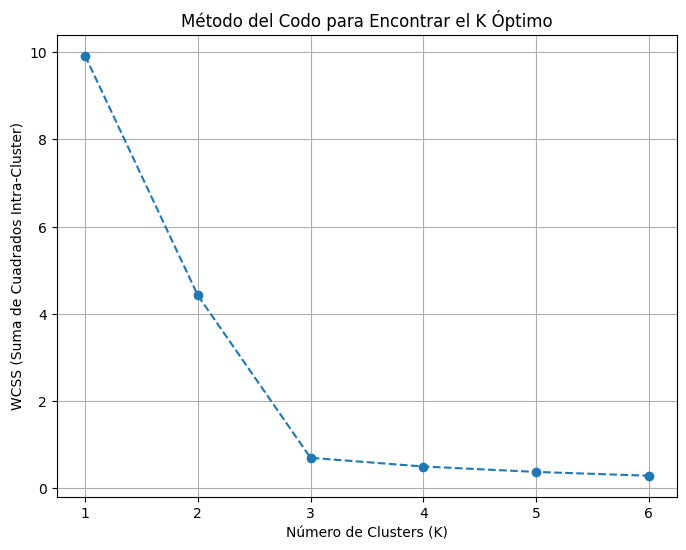

In [6]:
wcss = []
k_range = range(1, 7)

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X)
    wcss.append(km.inertia_)

# Mostramos los valores de inercia calculados para graficar el "codo"
print("\n--- MÉTODO DEL CODO (Valores de WCSS) ---")
for k, inertia in zip(k_range, wcss):
    print(f"K = {k} | WCSS = {inertia:.4f}")

plt.figure(figsize=(8, 6))
plt.plot(k_range, wcss, marker='o', linestyle='--')
plt.title('Método del Codo para Encontrar el K Óptimo')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('WCSS (Suma de Cuadrados Intra-Cluster)')
plt.grid(True)
plt.show()

### 5. Análisis del Silhouette Score para Diferentes K


--- Silhouette Scores para diferentes K ---
K = 2 | Silhouette Score = 0.5896
K = 3 | Silhouette Score = 0.7833
K = 4 | Silhouette Score = 0.7023
K = 5 | Silhouette Score = 0.5778
K = 6 | Silhouette Score = 0.6058


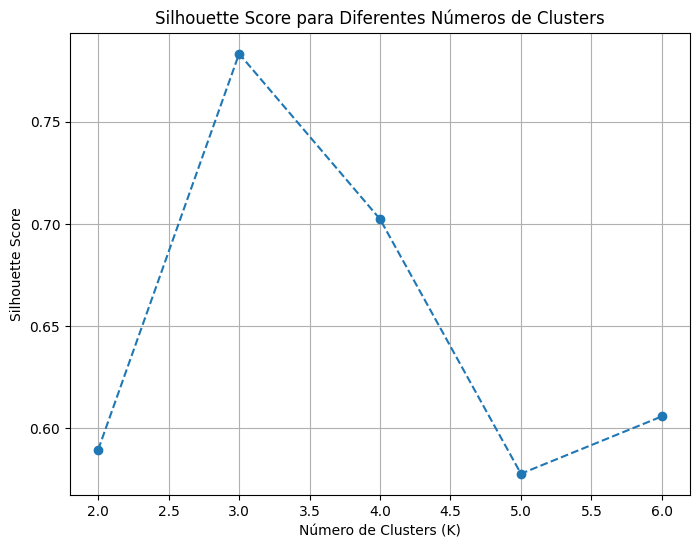

In [7]:
silhouette_scores = []
k_range_silhouette = range(2, 7) # Silhouette score requires at least 2 clusters

for k in k_range_silhouette:
    kmeans_model = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    cluster_labels = kmeans_model.fit_predict(X)
    score = silhouette_score(X, cluster_labels)
    silhouette_scores.append(score)

print("\n--- Silhouette Scores para diferentes K ---")
for k, score in zip(k_range_silhouette, silhouette_scores):
    print(f"K = {k} | Silhouette Score = {score:.4f}")

plt.figure(figsize=(8, 6))
plt.plot(k_range_silhouette, silhouette_scores, marker='o', linestyle='--')
plt.title('Silhouette Score para Diferentes Números de Clusters')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

### 6. Métricas Finales y Visualización de Clústeres (para K=3)

--- Evaluación del Modelo K-Means con K=3 ---

Silhouette Score para K=3: 0.7833


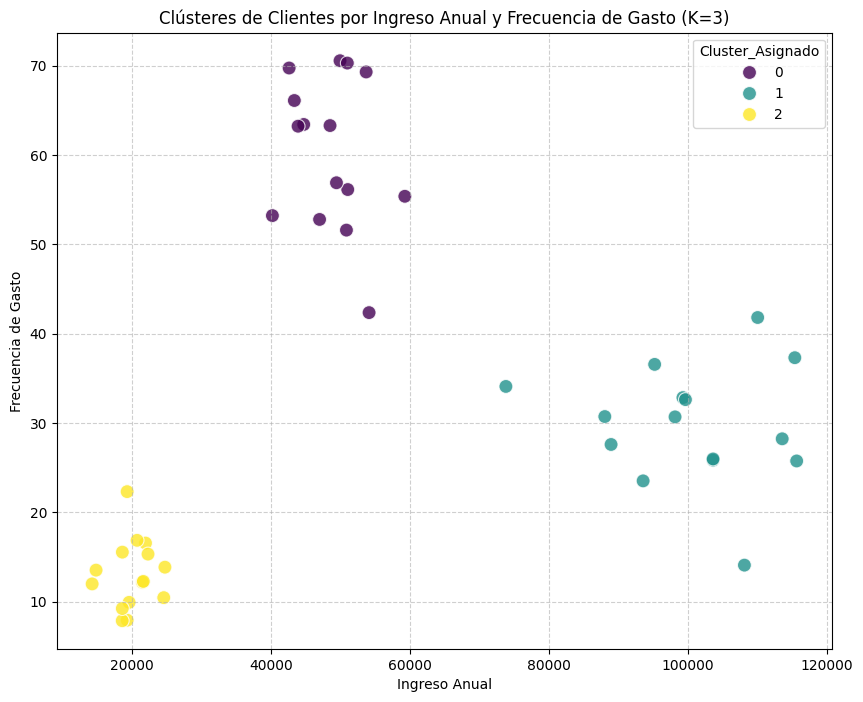


Distribución de Clientes por Clúster:


,count
Cluster_Asignado,
0,15
1,15
2,15


In [9]:
import seaborn as sns

print("--- Evaluación del Modelo K-Means con K=3 ---")
print(f"\nSilhouette Score para K=3: {silhouette_score(X, df['Cluster_Asignado']):.4f}")

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='Ingreso_Anual',
    y='Frecuencia_Gasto',
    hue='Cluster_Asignado',
    data=df,
    palette='viridis',
    s=100,  # size of points
    alpha=0.8
)
plt.title('Clústeres de Clientes por Ingreso Anual y Frecuencia de Gasto (K=3)')
plt.xlabel('Ingreso Anual')
plt.ylabel('Frecuencia de Gasto')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print("\nDistribución de Clientes por Clúster:")
display(df['Cluster_Asignado'].value_counts().sort_index())